# Why start investing today? What 40 young investors tell us

Presentation for school and college students, built from `Finance_data.csv` (40 survey respondents aged 21–35).

The notebook loads the data, computes the key figures, and generates one 4-panel image (`student_investing.png`) for the slides.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Finance_data.csv")
print(f"{len(df)} respondents, aged {df.age.min()}–{df.age.max()}")
df.head()

Matplotlib is building the font cache; this may take a moment.


40 respondents, aged 21–35


,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Female,34,Yes,1,2,5,3,7,6,4,...,1-3 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines
1,Female,23,Yes,4,3,2,1,5,6,7,...,More than 5 years,Weekly,20%-30%,Mutual Fund,Health Care,Dividend,Better Returns,Safe Investment,High Interest Rates,Financial Consultants
2,Male,30,Yes,3,6,4,2,5,1,7,...,3-5 years,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Tax Benefits,Assured Returns,Fixed Returns,Television
3,Male,22,Yes,2,1,3,7,6,4,5,...,Less than 1 year,Daily,10%-20%,Equity,Retirement Plan,Dividend,Fund Diversification,Tax Incentives,High Interest Rates,Internet
4,Female,24,No,2,1,3,6,4,5,7,...,Less than 1 year,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Risk Free,Internet


## Key figures

In [3]:
n = len(df)
invests = (df.Investment_Avenues == "Yes").sum()
stocks = (df.Stock_Marktet == "Yes").sum()
wealth = (df.Purpose == "Wealth Creation").sum()
long_term = (df.Duration != "Less than 1 year").sum()

print(f"Already invest:            {invests}/{n} ({invests/n:.1%})")
print(f"Invest in the stock market: {stocks}/{n} ({stocks/n:.1%})")
print(f"Goal = wealth creation:     {wealth}/{n} ({wealth/n:.1%})")
print(f"Hold for more than 1 year:  {long_term}/{n} ({long_term/n:.1%})")
print()
print("Preferred avenue:\n", df.Avenue.value_counts().to_string())
print()
print("Expected return:\n", df.Expect.value_counts().to_string())

Already invest:            37/40 (92.5%)
Invest in the stock market: 35/40 (87.5%)
Goal = wealth creation:     32/40 (80.0%)
Hold for more than 1 year:  38/40 (95.0%)

Preferred avenue:
 Avenue
Mutual Fund              18
Equity                   10
Fixed Deposits            9
Public Provident Fund     3

Expected return:
 Expect
20%-30%    32
30%-40%     5
10%-20%     3


In [4]:
# Products are ranked 1 (most preferred) to 7 (least preferred)
rank_cols = {
    "Mutual_Funds": "Mutual funds",
    "Equity_Market": "Equity (shares)",
    "Debentures": "Debentures",
    "Government_Bonds": "Government bonds",
    "Fixed_Deposits": "Fixed deposits",
    "PPF": "Public Provident Fund",
    "Gold": "Gold",
}
avg_rank = df[list(rank_cols)].mean().rename(rank_cols).sort_values()
avg_rank.round(2)

Public Provident Fund    2.02
Mutual funds             2.55
Equity (shares)          3.48
Fixed deposits           3.58
Government bonds         4.65
Debentures               5.75
Gold                     5.98
dtype: float64

In [5]:
# Compound-interest projection: 50 per month at a conservative 7% a year, until age 60
MONTHLY, RATE, END_AGE = 50, 0.07, 60

def projection(start_age):
    ages = np.arange(start_age, END_AGE + 1)
    r = RATE / 12
    months = (ages - start_age) * 12
    value = MONTHLY * ((1 + r) ** months - 1) / r
    return ages, value

ages20, val20 = projection(20)
ages30, val30 = projection(30)
print(f"Start at 20: {val20[-1]:,.0f} (paid in {MONTHLY*12*40:,})")
print(f"Start at 30: {val30[-1]:,.0f} (paid in {MONTHLY*12*30:,})")

Start at 20: 131,241 (paid in 24,000)
Start at 30: 60,999 (paid in 18,000)


## Image generation

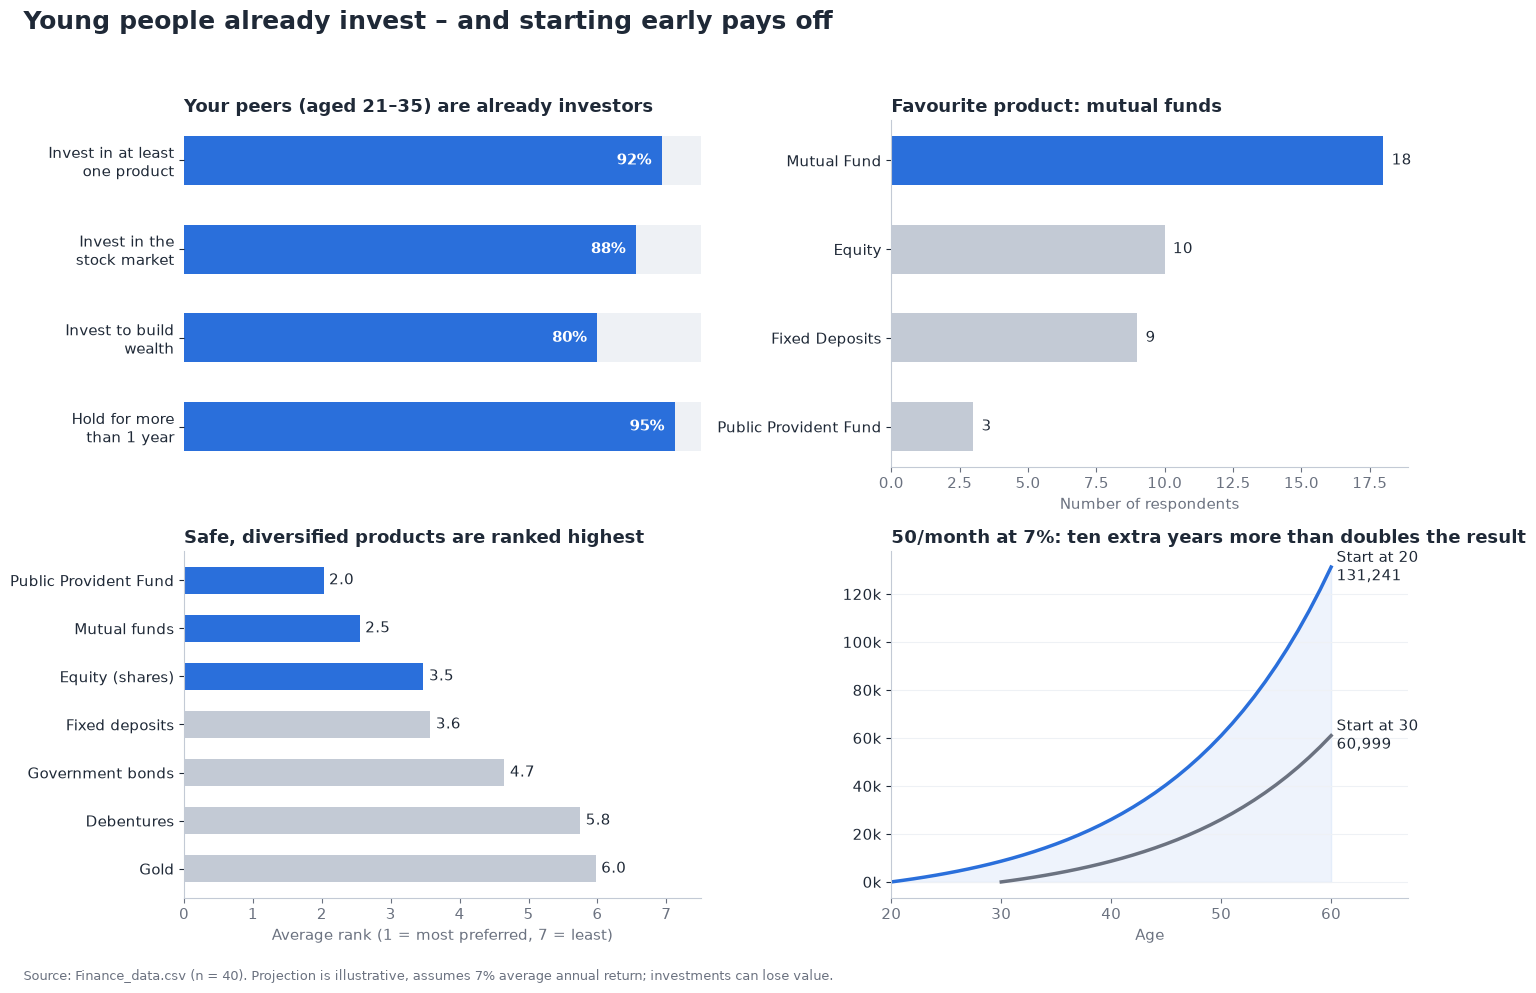

In [6]:
ACCENT, MUTED, INK, SOFT = "#2a6fdb", "#c3cad5", "#1f2937", "#6b7280"
plt.rcParams.update({
    "font.size": 11, "axes.edgecolor": MUTED, "axes.labelcolor": SOFT,
    "xtick.color": SOFT, "ytick.color": INK, "axes.titleweight": "bold",
    "axes.titlesize": 13, "axes.titlelocation": "left",
})

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Young people already invest – and starting early pays off",
             fontsize=18, fontweight="bold", color=INK, x=0.06, ha="left")

def clean(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

# 1. Share of peers who invest
ax = axes[0, 0]
labels = ["Invest in at least\none product", "Invest in the\nstock market",
          "Invest to build\nwealth", "Hold for more\nthan 1 year"]
values = np.array([invests, stocks, wealth, long_term]) / n * 100
bars = ax.barh(labels[::-1], values[::-1], color=ACCENT, height=0.55)
ax.barh(labels[::-1], 100 - values[::-1], left=values[::-1], color="#eef1f5", height=0.55)
for b, v in zip(bars, values[::-1]):
    ax.text(v - 2, b.get_y() + b.get_height() / 2, f"{v:.0f}%",
            va="center", ha="right", color="white", fontweight="bold")
ax.set_xlim(0, 100); ax.set_xticks([])
ax.set_title("Your peers (aged 21–35) are already investors", color=INK)
for s in ax.spines.values(): s.set_visible(False)

# 2. Preferred investment avenue
ax = axes[0, 1]
av = df.Avenue.value_counts().sort_values()
colors = [ACCENT if a == av.idxmax() else MUTED for a in av.index]
bars = ax.barh(av.index, av.values, color=colors, height=0.55)
for b, v in zip(bars, av.values):
    ax.text(v + 0.3, b.get_y() + b.get_height() / 2, f"{v}", va="center", color=INK)
ax.set_xlabel("Number of respondents")
ax.set_title("Favourite product: mutual funds", color=INK)
clean(ax)

# 3. Average preference rank (lower = preferred)
ax = axes[1, 0]
ar = avg_rank.sort_values(ascending=False)
top3 = set(avg_rank.index[:3])
colors = [ACCENT if p in top3 else MUTED for p in ar.index]
bars = ax.barh(ar.index, ar.values, color=colors, height=0.55)
for b, v in zip(bars, ar.values):
    ax.text(v + 0.08, b.get_y() + b.get_height() / 2, f"{v:.1f}", va="center", color=INK)
ax.set_xlim(0, 7.5)
ax.set_xlabel("Average rank (1 = most preferred, 7 = least)")
ax.set_title("Safe, diversified products are ranked highest", color=INK)
clean(ax)

# 4. Compound interest: start at 20 vs 30
ax = axes[1, 1]
ax.plot(ages20, val20, color=ACCENT, lw=2.5)
ax.plot(ages30, val30, color=SOFT, lw=2.5)
ax.fill_between(ages20, val20, color=ACCENT, alpha=0.08)
ax.text(END_AGE + 0.5, val20[-1], f"Start at 20\n{val20[-1]:,.0f}", va="center", color=INK)
ax.text(END_AGE + 0.5, val30[-1], f"Start at 30\n{val30[-1]:,.0f}", va="center", color=INK)
ax.set_xlim(20, END_AGE + 7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.grid(axis="y", color="#eef1f5")
ax.set_xlabel("Age")
ax.set_title(f"{MONTHLY}/month at {RATE:.0%}: ten extra years more than doubles the result", color=INK)
clean(ax)

fig.text(0.06, 0.01, "Source: Finance_data.csv (n = 40). Projection is illustrative, "
         "assumes 7% average annual return; investments can lose value.",
         color=SOFT, fontsize=9)
fig.tight_layout(rect=(0.04, 0.03, 1, 0.95))
fig.savefig("student_investing.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Presentation text (≈280 words)

**Why start investing today?**

The data comes from 40 young investors aged 21 to 35, people only a few years ahead of you. The message is clear: 37 of them (92.5%) already invest, and 35 (87.5%) put money in the stock market. Investing is not reserved for older or wealthy people. Your peers are already doing it.

The second chart shows where they put their money. Mutual funds come first (18 of 40), ahead of shares (10) and fixed deposits (9). Mutual funds spread your money across many companies, so one bad company does not sink your savings. That makes them a good fit for a first-time investor. The ranking chart tells the same story: the Public Provident Fund and mutual funds are rated highest, and riskier debentures come last. Young investors are ambitious, but careful.

Their goals are long-term. 80% invest to build wealth, and 38 of 40 keep their money invested for more than a year. That is why the last chart matters most. Thanks to compound interest, 50 a month started at age 20 grows to about 131,000 by age 60. The same 50 a month started at 30 reaches only about 61,000. Those ten extra years more than double the result, for just 6,000 more paid in. Time is the one asset you have more of than anyone else.

One warning: most respondents expect 20–30% returns a year, which is unrealistic. Our projection uses a conservative 7%, because good investing means patience, not quick wins.

Opening a student account with us gives you a savings account, a beginner-friendly mutual-fund plan, and an advisor to guide you. Start small, start now. Your future self will thank you.